In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import spacy
import gensim
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part2 feature-creation/code_features_extracts.csv')
leetcode_questions_df['num_of_contest'] = leetcode_questions_df.num_of_contest.astype('category')
leetcode_questions_df['question_number'] = leetcode_questions_df.question_number.astype('category')
leetcode_questions_df['finish_time'] = pd.to_datetime(leetcode_questions_df['finish_time'], format='%H:%M:%S').astype(int)
leetcode_questions_df['question_finish_time'] = pd.to_datetime(leetcode_questions_df['question_finish_time'], format='%H:%M:%S').astype(int)

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     61834 non-null  object  
 1   country                      61834 non-null  object  
 2   contest_url                  61834 non-null  object  
 3   num_of_contest               61834 non-null  category
 4   finish_time                  61834 non-null  int64   
 5   is_weekly                    61834 non-null  bool    
 6   rank                         61834 non-null  int64   
 7   score                        61834 non-null  int64   
 8   user_global_rank             61834 non-null  float64 
 9   question_number              61834 non-null  category
 10  question_language            61834 non-null  object  
 11  question_code                61834 non-null  object  
 12  question_finish_time         61834 non-null  int64   
 13  n

In [4]:
leetcode_questions_df.head()

,username,country,contest_url,num_of_contest,finish_time,is_weekly,rank,score,user_global_rank,question_number,...,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,fmota,Brazil,https://leetcode.com/contest/weekly-contest-36...,367,-2208988044000000000,True,2,17,486427.0,1,...,12,1,2,1,0.000000,0.0,0.045455,0.090909,0.045455,0.0
1,nicholask_17,Hong Kong,https://leetcode.com/contest/weekly-contest-36...,367,-2208988018000000000,True,3,17,27684.0,1,...,18,1,2,6,0.000000,0.0,0.032258,0.064516,0.193548,0.0
2,skywalkert,China,https://leetcode.com/contest/weekly-contest-36...,367,-2208987996000000000,True,4,17,16.0,1,...,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.0
3,hank55663,Taiwan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987929000000000,True,7,17,6234.0,1,...,12,1,1,5,0.037037,0.0,0.040000,0.040000,0.200000,0.2
4,DimmyT,Kazakhstan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987916000000000,True,8,17,702585.0,1,...,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.0


In [5]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']

In [6]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7162 entries, 28 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     7162 non-null   object  
 1   country                      7162 non-null   object  
 2   contest_url                  7162 non-null   object  
 3   num_of_contest               7162 non-null   category
 4   finish_time                  7162 non-null   int64   
 5   is_weekly                    7162 non-null   bool    
 6   rank                         7162 non-null   int64   
 7   score                        7162 non-null   int64   
 8   user_global_rank             7162 non-null   float64 
 9   question_number              7162 non-null   category
 10  question_language            7162 non-null   object  
 11  question_code                7162 non-null   object  
 12  question_finish_time         7162 non-null   int64   
 13  number

In [7]:
leetcode_questions_df.country.value_counts()

country
India                    3476
United States            1674
Canada                    388
China                     374
Japan                     238
Taiwan                    197
Ukraine                   138
Australia                 112
Singapore                 107
Romania                    69
Vietnam                    63
Belarus                    48
Poland                     35
Russia                     33
Kazakhstan                 30
Greece                     25
Brazil                     23
Palestinian Territory      16
Sweden                     14
Sri Lanka                  11
United Kingdom             11
Thailand                   11
Egypt                      11
Indonesia                   7
Iran                        7
Spain                       6
Bangladesh                  6
South Korea                 4
Pakistan                    4
Argentina                   3
Finland                     3
U.S. Virgin Islands         3
France                      3
Mo

<Axes: ylabel='Frequency'>

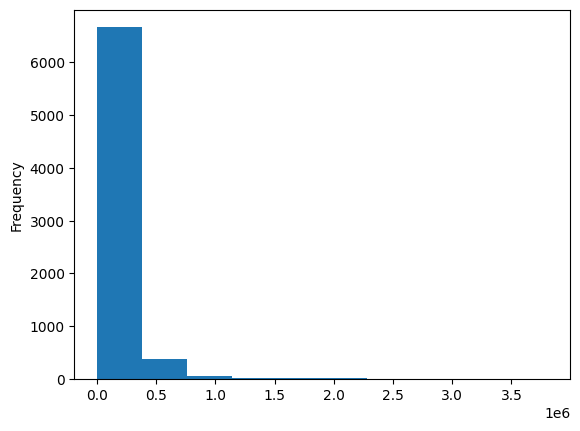

In [8]:
leetcode_questions_df['user_global_rank'].plot.hist()

In [9]:
leetcode_questions_df['user_global_rank'].max(), leetcode_questions_df['user_global_rank'].mean(), leetcode_questions_df['user_global_rank'].median()

(3807743.0, 89147.36986875175, 9018.0)

<Axes: ylabel='Frequency'>

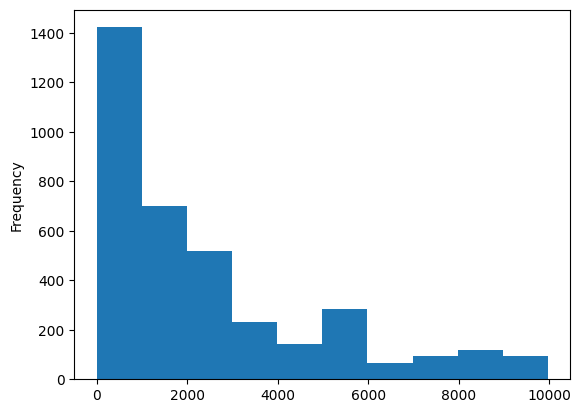

In [10]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['user_global_rank'] < 10000]

leetcode_questions_df['user_global_rank'].plot.hist()

In [11]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 100]
leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')

<ipython-input-11-22d56a376d39>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')


array([<Axes: title={'center': 'Australia'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Canada'}, ylabel='Frequency'>,
       <Axes: title={'center': 'China'}, ylabel='Frequency'>,
       <Axes: title={'center': 'India'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Japan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Taiwan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Ukraine'}, ylabel='Frequency'>,
       <Axes: title={'center': 'United States'}, ylabel='Frequency'>],
      dtype=object)

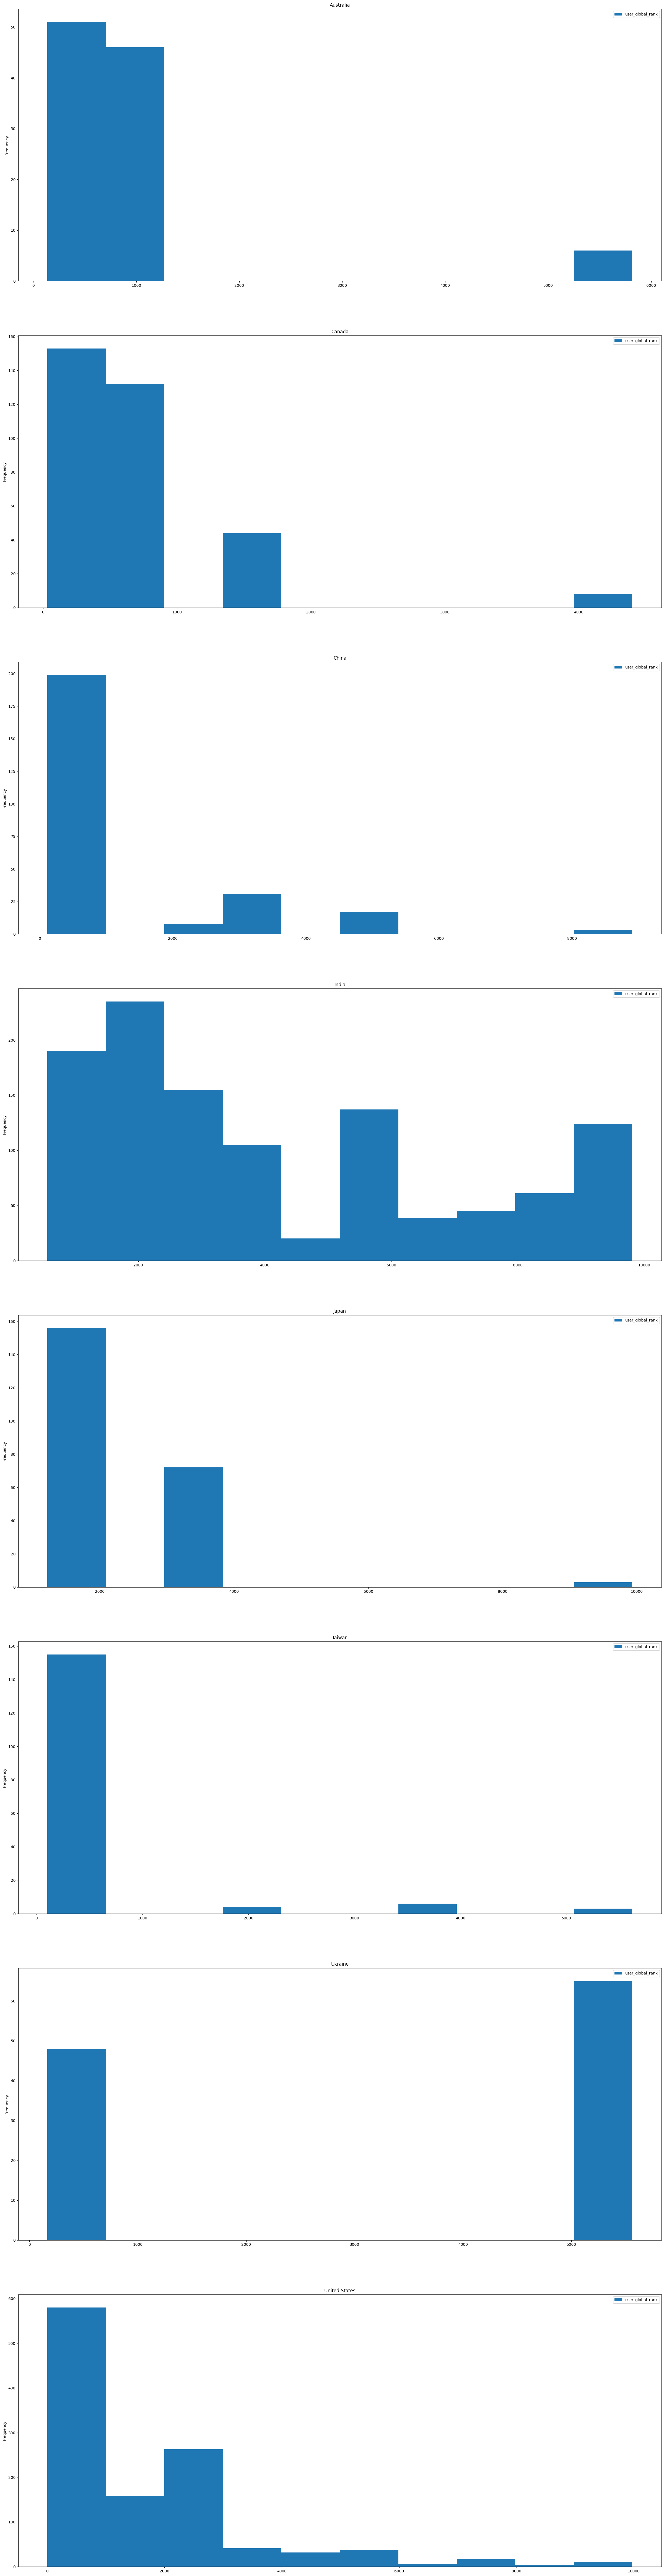

In [12]:
leetcode_questions_df.plot.hist(column=["user_global_rank"], by="country", figsize=(30, 120))

In [13]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df['country']

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3471 entries, 28 to 61755
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     3471 non-null   object  
 1   contest_url                  3471 non-null   object  
 2   num_of_contest               3471 non-null   category
 3   finish_time                  3471 non-null   int64   
 4   is_weekly                    3471 non-null   bool    
 5   rank                         3471 non-null   int64   
 6   score                        3471 non-null   int64   
 7   user_global_rank             3471 non-null   float64 
 8   question_number              3471 non-null   category
 9   question_language            3471 non-null   object  
 10  question_code                3471 non-null   object  
 11  question_finish_time         3471 non-null   int64   
 12  number_of_lines              3471 non-null   int64   
 13  names_

# Non text features

In [15]:
X_nontext=X[['user_global_rank', 'num_of_contest',
            'finish_time', 'is_weekly', 'score', 'username',
            'question_number', 'question_finish_time', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3471 entries, 28 to 61755
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   user_global_rank             3471 non-null   float64 
 1   num_of_contest               3471 non-null   category
 2   finish_time                  3471 non-null   int64   
 3   is_weekly                    3471 non-null   bool    
 4   score                        3471 non-null   int64   
 5   username                     3471 non-null   object  
 6   question_number              3471 non-null   category
 7   question_finish_time         3471 non-null   int64   
 8   number_of_lines              3471 non-null   int64   
 9   token_count                  3471 non-null   int64   
 10  variables_count              3471 non-null   int64   
 11  function_count               3471 non-null   int64   
 12  loop_count                   3471 non-null   int64   
 13  condit

In [16]:
X_train_nontext = X_nontext.iloc[:0]
X_test_nontext = X_nontext.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_nontext[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_nontext = X_train_nontext._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_nontext = X_test_nontext._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_nontext.drop('username', axis=1, inplace=True)
X_test_nontext.drop('username', axis=1, inplace=True)

In [17]:
#handle categorical columns

categorical = X_train_nontext.dtypes == 'category'

preprocess = make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

baseline_model = Pipeline([('encoder_scaler',preprocess),
                           ('svc',SVC())])

In [18]:
param_grid = [{'svc__C': np.logspace(0,3,16)}]
svc_cv= GridSearchCV(baseline_model, param_grid,cv=5,return_train_score=True)
svc_cv.fit(X_train_nontext, y_train)
print("nontext grid SVC train score ", svc_cv.score(X_train_nontext, y_train))
print("nontext grid SVC test score ", svc_cv.score(X_test_nontext, y_test))
print("nontext SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_nontext), average='weighted'))
print("nontext SVC test f1 score ", f1_score(y_test,svc_cv.predict(X_test_nontext), average='weighted'))
svc_cv.best_params_

nontext grid SVC train score  0.8530986993114001
nontext grid SVC test score  0.31388564760793464
nontext SVC train f1 score  0.8516733251461313
nontext SVC test f1 score  0.2798545318114479


{'svc__C': 39.810717055349734}

               precision    recall  f1-score   support

    Australia       0.10      0.04      0.06        51
       Canada       0.00      0.00      0.00        52
        China       0.06      0.03      0.04        61
        India       0.54      0.66      0.59       196
        Japan       0.00      0.00      0.00        22
       Taiwan       0.00      0.00      0.00       155
      Ukraine       0.00      0.00      0.00        48
United States       0.38      0.50      0.43       272

     accuracy                           0.31       857
    macro avg       0.13      0.15      0.14       857
 weighted avg       0.26      0.31      0.28       857

f1_score :  0.2798545318114479


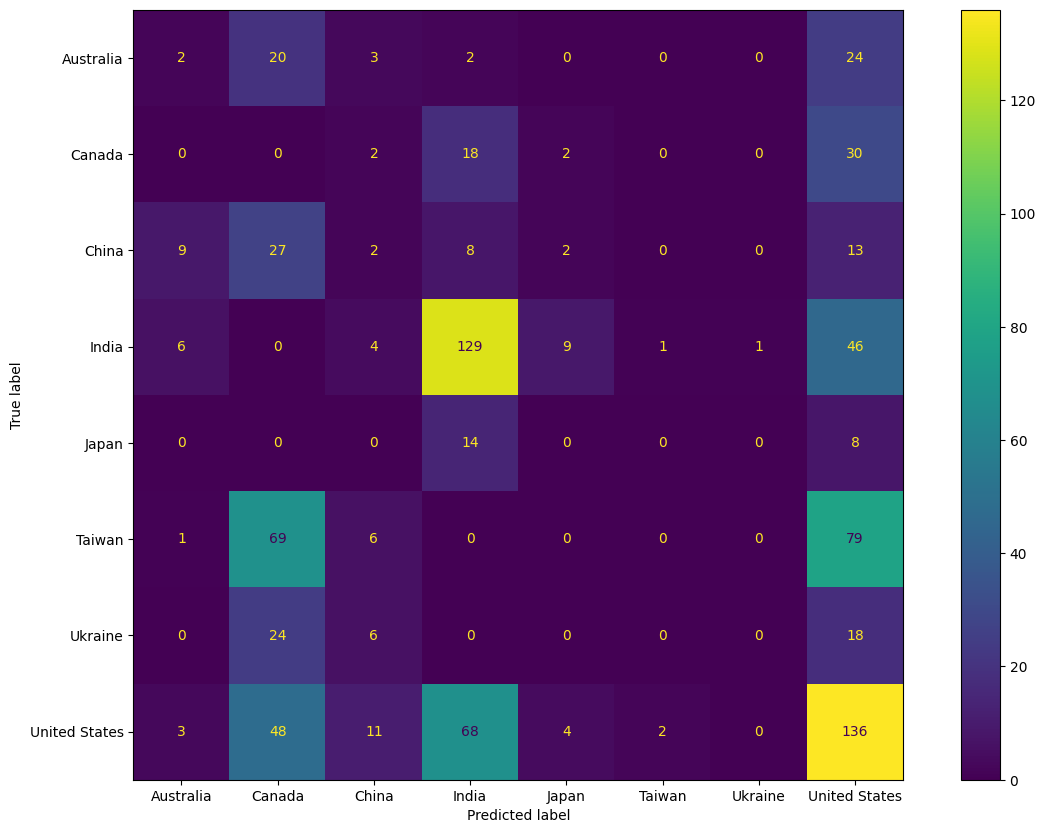

In [19]:
y_pred_test = svc_cv.predict(X_test_nontext)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# simple BOW

In [20]:
X_text=X[['username','question_code']]
X_train_text = X_text.iloc[:0]
X_test_text = X_text.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_text[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_text = X_train_text._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_text = X_test_text._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_text = X_train_text.question_code
X_test_text = X_test_text.question_code

In [21]:
custom_token_pattern = r'\b[A-Za-z_]\w*\b'

vect = CountVectorizer(stop_words='english', min_df=10, token_pattern=custom_token_pattern)
X_train_simple=vect.fit_transform(X_train_text)
X_test_simple=vect.transform(X_test_text)
print(vect.get_feature_names_out())

['a1' 'a2' 'a3' 'a4' 'a5' 'aaabaaaba' 'abs' 'abstract' 'access_times'
 'add' 'addall' 'added' 'addedge' 'addfirst' 'addlast' 'addnode' 'adj'
 'ak' 'al' 'algorithmcompilation' 'alphabet' 'anobject' 'anotherobject'
 'ans' 'ans2' 'append' 'apple' 'apply' 'area' 'areaofmaxdiagonal'
 'aresimilar' 'args' 'arr' 'arr1' 'arr2' 'array' 'arraycopy' 'arraydeque'
 'arrayindexoutofboundsexception' 'arraylist' 'arrays' 'arraysum'
 'arrayutil' 'available' 'ax' 'b' 'base' 'batterypercentages'
 'beautifulindices' 'beautifulsubstrings' 'best' 'better' 'bfs'
 'bifunction' 'binary' 'binaryindextree' 'binarysearch' 'bit' 'bitcount'
 'bitlimit' 'bitv' 'bl' 'block' 'blocklist' 'blocks' 'blocksum' 'boolean'
 'bottomleft' 'break' 'buffer' 'build' 'buildheight' 'buildrmq' 'c' 'c1'
 'c2' 'calc' 'calculate' 'calculator' 'calling' 'canpartitionkblocks'
 'canpartitionksubsets' 'cansortarray' 'capacity' 'case' 'cc' 'ceil'
 'ceiling' 'ch' 'change' 'changed' 'changeindices' 'char' 'character'
 'charat' 'chars' 'charseq

In [22]:
svc = SVC().fit(X_train_simple, y_train)
print("simple BOW SVC train score ",svc.score(X_train_simple, y_train))
print("simple BOW SVC test score ",svc.score(X_test_simple, y_test))
print("simple BOW SVC train f1 score ", f1_score(y_train, svc.predict(X_train_simple), average='weighted'))
print("simple BOW SVC test f1 score ", f1_score(y_test, svc.predict(X_test_simple), average='weighted'))

simple BOW SVC train score  0.4020657995409334
simple BOW SVC test score  0.2543757292882147
simple BOW SVC train f1 score  0.28467732310547406
simple BOW SVC test f1 score  0.13840422711056585


# n-grams tf-idf

In [23]:
wordnet_lem = WordNetLemmatizer()

X_train_lemma=X_train_text.apply(wordnet_lem.lemmatize)
X_test_lemma=X_test_text.apply(wordnet_lem.lemmatize)

In [24]:
tfidf_pipeline = make_pipeline(CountVectorizer(stop_words='english',ngram_range=(2,10),min_df=10),
                      Normalizer(),
                      TfidfTransformer(),
                      SVC(random_state=0),memory="cache_folder")

In [25]:
param_grid = [{
    'countvectorizer__ngram_range':[(2, 5), (5,9), (2,10)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(tfidf_pipeline, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_lemma, y_train)

print("n-grams grid SVC train score ",svc_cv.score(X_train_lemma, y_train))
print("n-grams grid SVC test score ",svc_cv.score(X_test_lemma, y_test))
print("n-grams SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_lemma), average='weighted'))
print("n-grams SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_lemma), average='weighted'))
svc_cv.best_params_

n-grams grid SVC train score  0.9908186687069626
n-grams grid SVC test score  0.31738623103850644
n-grams SVC train f1 score  0.9908142467772767
n-grams SVC test f1 score  0.2443055022874085


{'countvectorizer__ngram_range': (2, 5), 'svc__C': 100.0}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

    Australia       0.00      0.00      0.00        51
       Canada       0.08      0.10      0.09        52
        China       0.05      0.02      0.02        61
        India       0.37      0.64      0.47       196
        Japan       0.00      0.00      0.00        22
       Taiwan       0.00      0.00      0.00       155
      Ukraine       0.00      0.00      0.00        48
United States       0.34      0.51      0.41       272

     accuracy                           0.32       857
    macro avg       0.10      0.16      0.12       857
 weighted avg       0.20      0.32      0.24       857

f1_score :  0.2443055022874085


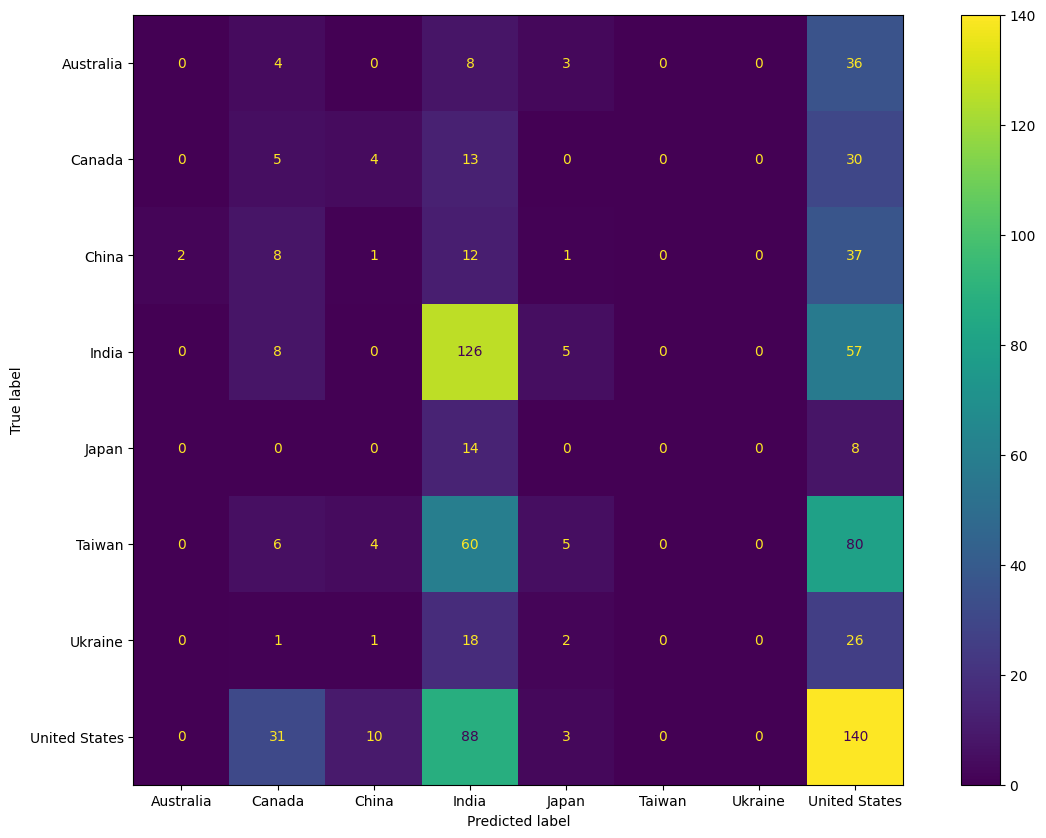

In [26]:
y_pred_test = svc_cv.predict(X_test_lemma)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [27]:
results = pd.DataFrame(svc_cv.cv_results_)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_countvectorizer__ngram_range,param_svc__C,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,7.474309,0.891372,1.965279,0.872563,"(2, 5)",0.01,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.349904,0.349904,0.349904,...,0.350038,0.000268,13,0.350072,0.350072,0.350072,0.350072,0.349904,0.350038,0.000067
1,6.173023,0.870884,2.081295,0.606304,"(2, 5)",0.1,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.353728,0.355641,0.363289,...,0.362668,0.008330,11,0.370158,0.367288,0.371593,0.365854,0.357075,0.366393,0.005082
2,6.155323,0.724665,1.381023,0.310858,"(2, 5)",1.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.478011,0.495220,0.487572,...,0.506131,0.024181,5,0.833572,0.819703,0.807747,0.800574,0.768642,0.806048,0.021800
3,6.885514,0.905119,1.627479,0.687847,"(2, 5)",10.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.502868,0.552581,0.541109,...,0.562003,0.044655,2,0.994739,0.985175,0.982305,0.981827,0.981358,0.985081,0.005009
4,7.287334,1.035831,1.859491,0.659946,"(2, 5)",100.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.493308,0.558317,0.537285,...,0.563158,0.054370,1,0.996174,0.991392,0.989479,0.988522,0.988528,0.990819,0.002875
5,8.255593,0.920972,1.387542,0.437681,"(5, 9)",0.01,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.349904,0.349904,0.349904,...,0.350038,0.000268,13,0.350072,0.350072,0.350072,0.350072,0.349904,0.350038,0.000067
6,5.316959,1.511686,1.594767,0.632982,"(5, 9)",0.1,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.359465,0.370937,0.384321,...,0.376440,0.010835,10,0.383549,0.382114,0.381157,0.382592,0.371893,0.380261,0.004254
7,4.729470,1.162482,1.309847,0.617605,"(5, 9)",1.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.399618,0.407266,0.413002,...,0.402850,0.035301,7,0.593018,0.588235,0.595409,0.576279,0.554015,0.581391,0.015193
8,5.733811,1.098218,1.476963,1.094993,"(5, 9)",10.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.399618,0.390057,0.370937,...,0.383342,0.039690,9,0.800096,0.795791,0.812052,0.769010,0.751434,0.785677,0.022164
9,5.011542,0.510237,1.146391,0.458325,"(5, 9)",100.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.405354,0.397706,0.369025,...,0.387167,0.039313,8,0.821616,0.817312,0.829747,0.788140,0.775813,0.806526,0.020807


#Pretrained Work Vectors

In [28]:
%%python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 2.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [29]:
nlp = spacy.load("en_core_web_lg", disable=["tagger", "parser", "ner","lemmatizer"])
docs_train = [nlp(d).vector for d in X_train_text]
docs_test = [nlp(d).vector for d in X_test_text]

In [30]:
X_train_w2v = np.vstack(docs_train)
X_test_w2v = np.vstack(docs_test)
X_train_w2v.shape, X_test_w2v.shape

((2614, 300), (857, 300))

In [31]:
param_grid = [{'C':np.logspace(-2,2,20)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_w2v, y_train)
print("spacy grid SVC train score ",svc_cv.score(X_train_w2v, y_train))
print("spacy grid SVC test score ",svc_cv.score(X_test_w2v, y_test))
print("spacy SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_w2v), average='weighted'))
print("spacy SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_w2v), average='weighted'))
svc_cv.best_params_

spacy grid SVC train score  0.7314460596786534
spacy grid SVC test score  0.3943990665110852
spacy SVC train f1 score  0.7144121849070143
spacy SVC test f1 score  0.3101328360097054


{'C': 37.92690190732246}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

    Australia       0.00      0.00      0.00        51
       Canada       0.12      0.15      0.13        52
        China       0.39      0.15      0.21        61
        India       0.47      0.84      0.61       196
        Japan       0.00      0.00      0.00        22
       Taiwan       0.00      0.00      0.00       155
      Ukraine       0.00      0.00      0.00        48
United States       0.39      0.57      0.47       272

     accuracy                           0.39       857
    macro avg       0.17      0.21      0.18       857
 weighted avg       0.27      0.39      0.31       857

f1_score :  0.3101328360097054


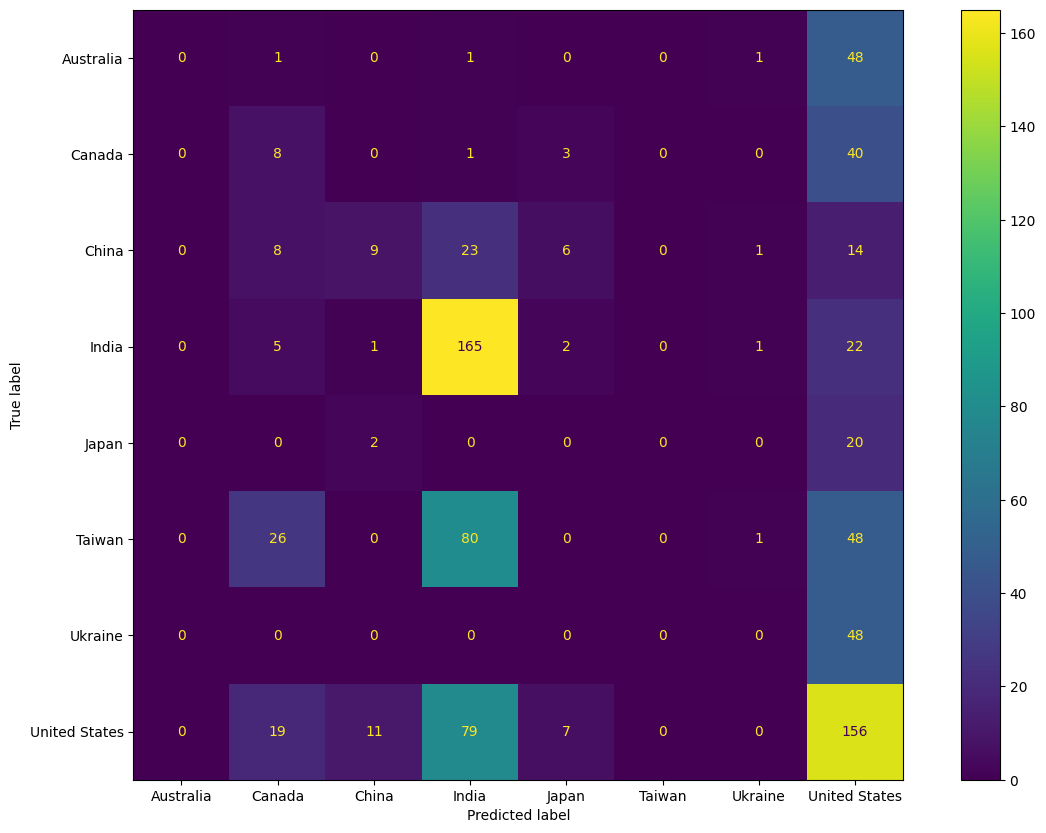

In [32]:
y_pred_test = svc_cv.predict(X_test_w2v)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [33]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [34]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [35]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((2614, 50), (857, 50))

In [36]:
param_grid = [{'C':np.logspace(-2,2,20)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_doc2vec, y_train)
print("gensim grid SVC train score ",svc_cv.score(X_train_doc2vec, y_train))
print("gensim grid SVC test score ",svc_cv.score(X_test_doc2vec, y_test))
print("gensim SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_doc2vec), average='weighted'))
print("gensim SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_doc2vec), average='weighted'))
svc_cv.best_params_

gensim grid SVC train score  0.8527161438408569
gensim grid SVC test score  0.3278879813302217
gensim SVC train f1 score  0.8513458609997926
gensim SVC test f1 score  0.2564905436539973


{'C': 8.858667904100823}

# Combine Text and non text features

In [37]:
X_train_combined=pd.concat([X_train_lemma,X_train_nontext],axis=1)

X_test_combined=pd.concat([X_test_lemma,X_test_nontext],axis=1)

X_train_combined.head(5)

,question_code,user_global_rank,num_of_contest,finish_time,is_weekly,score,question_number,question_finish_time,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,class Solution {\n public int[] findIndices...,2545.0,367,-2208987386000000000,True,17,1,-2208988681000000000,19,22,12,1,2,1,0.0,0.0,0.045455,0.090909,0.045455,0.0
1,class Solution {\n public int[] findIndices...,638.0,367,-2208986902000000000,True,17,1,-2208988476000000000,14,21,11,1,2,1,0.0,0.0,0.047619,0.095238,0.047619,0.0
2,class Solution {\n public int[] findIndices...,1273.0,367,-2208986514000000000,True,17,1,-2208988720000000000,12,19,10,1,2,1,0.0,0.0,0.052632,0.105263,0.052632,0.0
3,import java.util.*;\n\nclass Solution {\n p...,327.0,367,-2208986455000000000,True,17,1,-2208988616000000000,21,27,16,1,2,2,0.0,0.0,0.037037,0.074074,0.074074,0.0
4,class Solution {\n public int[] findIndices...,2909.0,367,-2208985742000000000,True,17,1,-2208988662000000000,16,22,13,1,2,1,0.0,0.0,0.045455,0.090909,0.045455,0.0


In [38]:
X_train_combined.dtypes

question_code                    object
user_global_rank                float64
num_of_contest                 category
finish_time                       int64
is_weekly                          bool
score                             int64
question_number                category
question_finish_time              int64
number_of_lines                   int64
token_count                       int64
variables_count                   int64
function_count                    int64
loop_count                        int64
condition_count                   int64
single_line_comment_density     float64
multiline_comment_density       float64
function_density                float64
loop_density                    float64
condition_density               float64
comment_tokens_density          float64
dtype: object

In [39]:
categorical = X_train_combined.dtypes == 'category'

tfidf = make_pipeline(CountVectorizer(stop_words='english', ngram_range=(2,10), min_df=10, token_pattern=custom_token_pattern),
                      Normalizer(),
                      TfidfTransformer(),memory="cache_folder")

make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

preprocessor_combined = make_column_transformer((tfidf, 'question_code'),
                                                (StandardScaler(), ~categorical & (X_train_combined.dtypes != object)),
                                                (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

combine_model = Pipeline([('transformer',preprocessor_combined),
                           ('svc',SVC(random_state=0))])

In [40]:
scores = cross_val_score(combine_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.5214215072196215


In [42]:
param_grid = [{
    'transformer__pipeline__countvectorizer__ngram_range':[(2, 5), (3, 6)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(combine_model, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_combined, y_train)

print("combined grid SVC train score ",svc_cv.score(X_train_combined, y_train))
print("combined grid SVC test score ",svc_cv.score(X_test_combined, y_test))
print("combined SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_combined), average='weighted'))
print("combined SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_combined), average='weighted'))
svc_cv.best_params_

combined grid SVC train score  0.9996174445294568
combined grid SVC test score  0.2928821470245041
combined SVC train f1 score  0.9996170666837608
combined SVC test f1 score  0.2620460652267612


{'svc__C': 100.0,
 'transformer__pipeline__countvectorizer__ngram_range': (2, 5)}

               precision    recall  f1-score   support

    Australia       1.00      1.00      1.00        52
       Canada       1.00      1.00      1.00       285
        China       1.00      0.99      1.00       197
        India       1.00      1.00      1.00       915
        Japan       1.00      1.00      1.00       209
       Taiwan       1.00      1.00      1.00        13
      Ukraine       1.00      1.00      1.00        65
United States       1.00      1.00      1.00       878

     accuracy                           1.00      2614
    macro avg       1.00      1.00      1.00      2614
 weighted avg       1.00      1.00      1.00      2614

f1_score :  0.9996170666837608


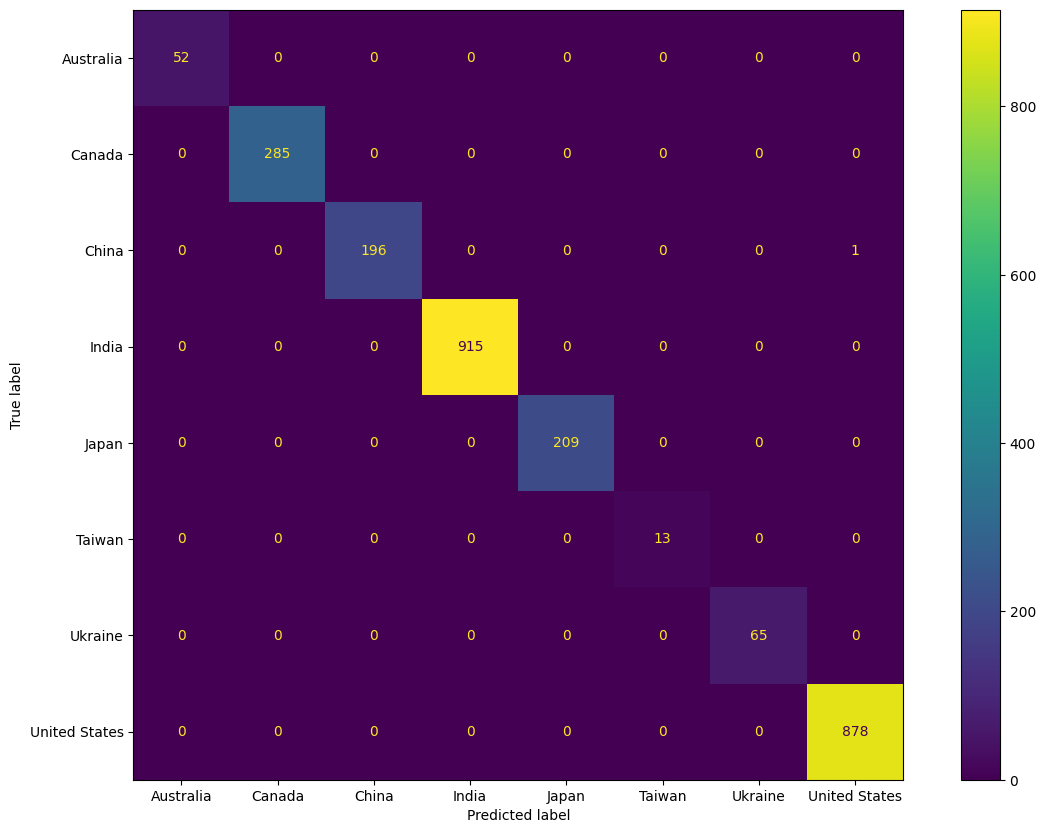

In [43]:
y_pred_train = svc_cv.predict(X_train_combined)

print(classification_report(y_train, y_pred_train))

print("f1_score : ",f1_score(y_train, y_pred_train, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, y_pred_train), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

    Australia       0.31      0.08      0.12        51
       Canada       0.00      0.02      0.01        52
        China       0.03      0.02      0.02        61
        India       0.54      0.66      0.60       196
        Japan       0.00      0.00      0.00        22
       Taiwan       0.00      0.00      0.00       155
      Ukraine       0.00      0.00      0.00        48
United States       0.32      0.43      0.37       272

     accuracy                           0.29       857
    macro avg       0.15      0.15      0.14       857
 weighted avg       0.25      0.29      0.26       857

f1_score :  0.2620460652267612


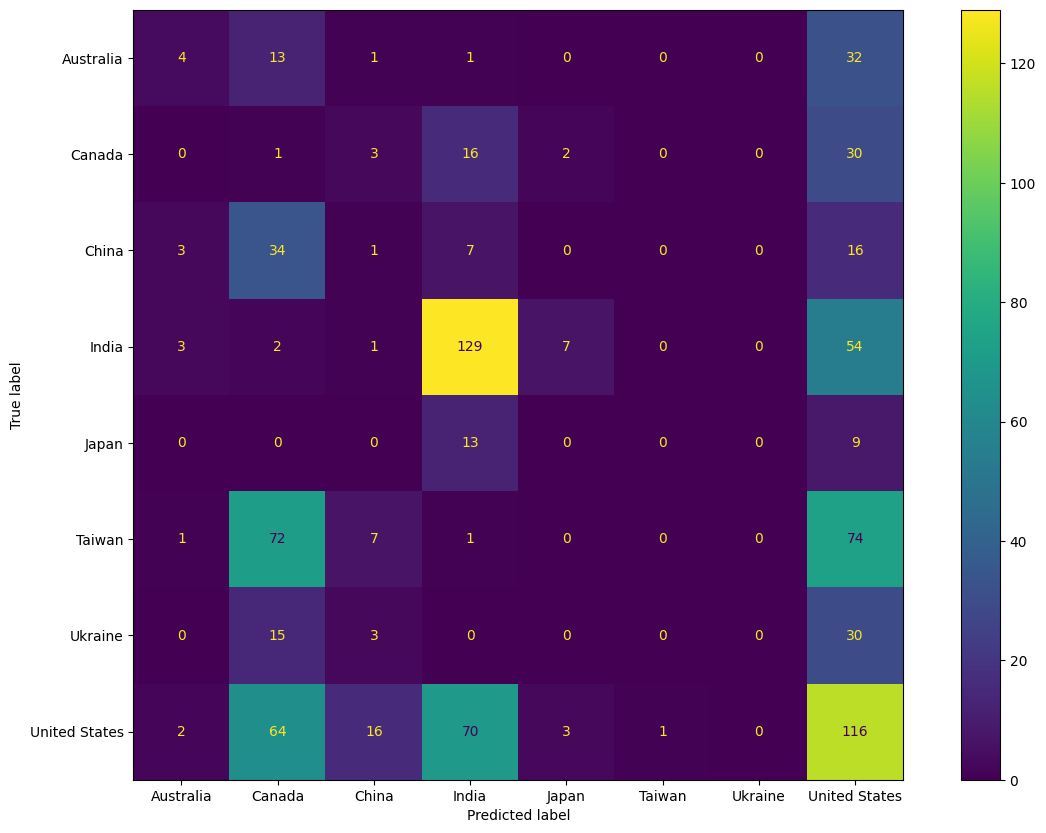

In [44]:
y_pred_test = svc_cv.predict(X_test_combined)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()